In [21]:
import networkx as nx
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [22]:
from collections import defaultdict

import networkx as nx
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

try:
    from google.colab import files
    DATA_PATH = list(files.upload())[0]
except ImportError:
    DATA_PATH = "trade-register.csv"          # edit if running locally

CHECK_YEARS = [1964, 1984, 1999, 2024]
COUNTRIES_TO_TRACK = ["United States", "Soviet Union", "Russia", "China",
                      "India", "Germany", "France", "United Kingdom"]
MIN_NODES = 20

Saving trade-register.csv to trade-register (1).csv


In [23]:
# ---- load and clean -------------------------------------------------------
with open(DATA_PATH, encoding="latin-1") as fh:
    header = next(i for i, line in enumerate(fh) if "Recipient,Supplier" in line)

raw = pd.read_csv(DATA_PATH, skiprows=header, encoding="latin-1", low_memory=False)
raw.columns = raw.columns.str.strip()

data = raw.dropna(subset=["Recipient", "Supplier"]).copy()
for col in ["Recipient", "Supplier"]:
    data[col] = data[col].astype(str).str.strip()
    data = data[~data[col].str.endswith("*")].copy()             # non-state actors
    data = data[~data[col].str.contains("unknown", case=False)].copy()
data = data[data["Recipient"] != data["Supplier"]].copy()

In [24]:
# ---- annual supplier -> recipient edges, weighted by total-order TIV ------
order_year = pd.to_numeric(data["Year of order"], errors="coerce")
tiv = pd.to_numeric(data["SIPRI TIV for total order"], errors="coerce")

weights = defaultdict(float)
for supplier, recipient, year, value in zip(data["Supplier"], data["Recipient"],
                                            order_year, tiv):
    if pd.isna(year) or pd.isna(value) or value < 0:
        continue
    year = int(year)
    if not 1950 <= year <= 2024:
        continue
    value = 0.25 if value == 0 else float(value)   # SIPRI 0 = below 0.5m
    if year < 1992:                                # pre-1992 harmonisation
        supplier = "Soviet Union" if supplier == "Russia" else supplier
        recipient = "Soviet Union" if recipient == "Russia" else recipient
    if supplier != recipient:
        weights[(supplier, recipient, year)] += value

edges = pd.DataFrame([(s, r, y, w) for (s, r, y), w in weights.items()],
                     columns=["supplier", "recipient", "year", "weight"])
print(f"{len(edges):,} annual dyad edges, "
      f"{len(set(edges.supplier) | set(edges.recipient))} countries")

15,264 annual dyad edges, 195 countries


In [25]:
def directed_year_graph(frame: pd.DataFrame, year: int) -> nx.DiGraph:
    """Directed weighted graph for one year: supplier -> recipient."""
    graph = nx.DiGraph()
    for row in frame[frame["year"] == year].itertuples(index=False):
        graph.add_edge(row.supplier, row.recipient, weight=float(row.weight))
    return graph

In [26]:
def bowtie(graph: nx.DiGraph) -> dict:
    """
    Bow-tie decomposition.

    SCC  — countries that both buy and sell within the same year, reachable
           from each other; the mutual core of the market.
    IN   — reach the core but are not reached by it: pure sellers.
    OUT  — reached by the core but do not reach it: pure buyers.
    OTHER— tendrils and disconnected pairs.

    The SCC size is the substantive quantity here: it counts states that are
    simultaneously suppliers and recipients, which an undirected projection
    cannot distinguish from any other well-connected node.
    """
    if graph.number_of_nodes() == 0:
        return {}
    core = max(nx.strongly_connected_components(graph), key=len)
    in_set, out_set, other = set(), set(), set()
    for node in graph.nodes():
        if node in core:
            continue
        if nx.descendants(graph, node) & core:
            in_set.add(node)
        elif nx.ancestors(graph, node) & core:
            out_set.add(node)
        else:
            other.add(node)
    return {"scc": core, "in": in_set, "out": out_set, "other": other}

In [27]:
years = sorted(edges["year"].unique())
role_rows, structure_rows, bowtie_members = [], [], []

print(f"Computing directed diagnostics for {len(years)} years ...")
for year in years:
    graph = directed_year_graph(edges, year)
    if graph.number_of_nodes() < MIN_NODES:
        continue

    parts = bowtie(graph)

    # HITS gives each country two scores instead of one: the hub score is
    # seller-side centrality, the authority score buyer-side. A country can
    # score high on one, both, or neither -- which is exactly the distinction
    # a single coreness value collapses.
    try:
        hubs, authorities = nx.hits(graph, max_iter=1000, normalized=True)
    except Exception:
        hubs = authorities = {n: np.nan for n in graph.nodes()}

    for node in graph.nodes():
        if node in parts["scc"]:
            role = "core (buys and sells)"
        elif node in parts["in"]:
            role = "seller only"
        elif node in parts["out"]:
            role = "buyer only"
        else:
            role = "other"
        role_rows.append({
            "country": node, "year": year, "bowtie_role": role,
            "hub_score": float(hubs.get(node, np.nan)),
            "authority_score": float(authorities.get(node, np.nan)),
            "out_strength": float(graph.out_degree(node, weight="weight")),
            "in_strength": float(graph.in_degree(node, weight="weight")),
        })

    # Negative out-in assortativity means heavy exporters connect to light
    # importers rather than to each other: the directed signature of a
    # hub-and-spoke market.
    try:
        assortativity = nx.degree_assortativity_coefficient(graph, x="out", y="in")
    except Exception:
        assortativity = np.nan

    structure_rows.append({
        "year": year,
        "nodes": graph.number_of_nodes(),
        "edges": graph.number_of_edges(),
        "scc_size": len(parts["scc"]),
        "sellers_only": len(parts["in"]),
        "buyers_only": len(parts["out"]),
        "other": len(parts["other"]),
        "reciprocity": nx.reciprocity(graph),
        "out_in_assortativity": assortativity,
    })
    bowtie_members.append({
        "year": year,
        "core_members": ", ".join(sorted(parts["scc"])),
    })

directed_roles = pd.DataFrame(role_rows)
directed_structure = pd.DataFrame(structure_rows)
bowtie_core = pd.DataFrame(bowtie_members)

print(directed_structure.tail(10).to_string(index=False))

print("\nMutual core in the benchmark years")
for year in CHECK_YEARS:
    row = bowtie_core[bowtie_core["year"] == year]
    if not row.empty:
        print(f"  {year}: {row['core_members'].iloc[0]}")

Computing directed diagnostics for 75 years ...
 year  nodes  edges  scc_size  sellers_only  buyers_only  other  reciprocity  out_in_assortativity
 2015    125    298        13             2          106      4     0.013423             -0.162741
 2016    113    250        13             3           75     22     0.024000             -0.249646
 2017    108    262        12             3           72     21     0.015267             -0.207110
 2018    128    265        13             1          107      7     0.037736             -0.211873
 2019    113    254         9             1           84     19     0.047244             -0.157859
 2020    108    261        23             7           63     15     0.068966             -0.233643
 2021    113    257        11             1           87     14     0.038911             -0.151871
 2022    119    299        14             2           74     29     0.040134             -0.266873
 2023    118    298        17             0           81     

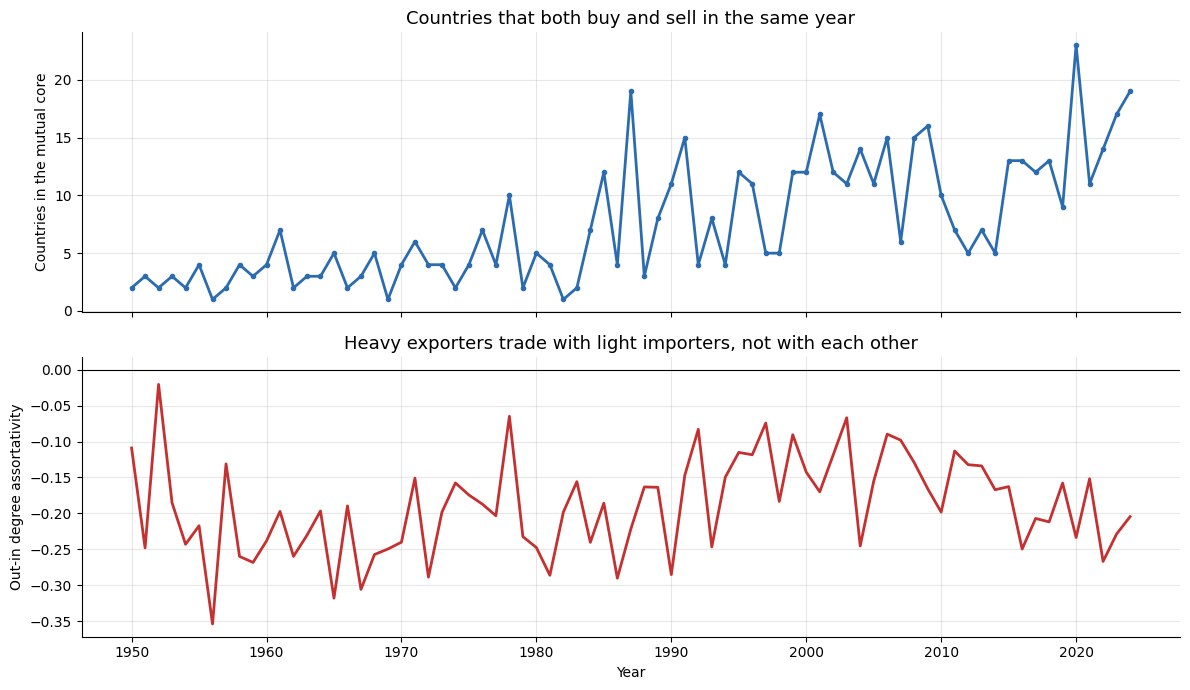

In [31]:
fig, axes = plt.subplots(2, 1, figsize=(12, 7), sharex=True)

axes[0].plot(directed_structure["year"], directed_structure["scc_size"],
             color="#2b6cb0", lw=2, marker="o", ms=3)
axes[0].set_ylabel("Countries in the mutual core")
axes[0].set_title("Countries that both buy and sell in the same year", fontsize=13)

axes[1].axhline(0, color="black", lw=0.8)
axes[1].plot(directed_structure["year"], directed_structure["out_in_assortativity"],
             color="#c53030", lw=2)
axes[1].set_ylabel("Out-in degree assortativity")
axes[1].set_xlabel("Year")
axes[1].set_title("Heavy exporters trade with light importers, not with each other",
                  fontsize=13)

for ax in axes:
    ax.grid(alpha=0.3)
    ax.spines[["top", "right"]].set_visible(False)

fig.tight_layout()
fig.savefig("directed_structure.pdf", bbox_inches="tight")
plt.show()

In [29]:
# ---- Role stability --------------------------------------------------------
# How consistently does a country occupy the same bow-tie role? Unlike the LAGO
# community labels, these roles are defined independently in each year and
# carry no arbitrary numbering, so they can be compared across time directly.

role_mix = (directed_roles.groupby(["country", "bowtie_role"]).size()
            .unstack(fill_value=0))
role_mix["years_active"] = role_mix.sum(axis=1)
role_share = (role_mix.drop(columns="years_active")
              .div(role_mix["years_active"], axis=0))
role_share["years_active"] = role_mix["years_active"]

frequent_core = (role_share[role_share["years_active"] >= 10]
                 .sort_values("core (buys and sells)", ascending=False))
print("\nCountries most often in the mutual core (10+ active years)")
print(frequent_core.head(20).round(3).to_string())
role_share.to_csv("bowtie_role_shares.csv")


Countries most often in the mutual core (10+ active years)
bowtie_role     buyer only  core (buys and sells)  other  seller only  years_active
country                                                                            
United States        0.000                  0.720  0.133        0.147            75
United Kingdom       0.067                  0.680  0.147        0.107            75
France               0.093                  0.587  0.187        0.133            75
Germany              0.192                  0.562  0.178        0.068            73
Canada               0.200                  0.560  0.173        0.067            75
Italy                0.307                  0.467  0.173        0.053            75
Israel               0.347                  0.413  0.173        0.067            75
Netherlands          0.333                  0.413  0.213        0.040            75
Sweden               0.405                  0.324  0.122        0.149            74
Norway          